<a href="https://colab.research.google.com/github/Ritik-Kumar-2002/Digit-Classification-/blob/main/MNIST_Dataset_digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# !pip install -q kaggle
# ! pip install keras_tuner

## ***MNIST DataSet Digit Classification***

In [103]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp /content/kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [104]:
ls


digital-mnist-dataset.zip  mnist_data/  sample_data/  Sequential_tuning/


In [105]:
!kaggle datasets list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


Download the dataset from kaggle

In [106]:
!kaggle datasets download -d wasiqaliyasir/digital-mnist-dataset

Dataset URL: https://www.kaggle.com/datasets/wasiqaliyasir/digital-mnist-dataset
License(s): apache-2.0
digital-mnist-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


UnZIP the MNIST dataset file

In [107]:
!unzip -o /content/digital-mnist-dataset.zip -d /content/mnist_data

Archive:  /content/digital-mnist-dataset.zip
  inflating: /content/mnist_data/mnist.csv  


# ***MNIST dataset digit Classification***

Import Libraries

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Load a dataset

In [109]:
df = pd.read_csv('./mnist_data/mnist.csv')

# **Perform EDA**

Step1. Dataset Understanding

In [110]:
print('Dataframe Shape: ',df.shape)

df.head(5)

Dataframe Shape:  (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [111]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


Step2. DataCleaning and data preprocessing

In [113]:
# Check Null values
df.isnull().sum() # No null value found

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


# *Split a dataset into training and testing data*

In [114]:
from sklearn.model_selection import train_test_split

# Split a dataset
X = df.iloc[:,1:]
Y = df.iloc[:,0]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [115]:
X_train

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
9254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1561,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1670,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6087,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6669,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5191,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5390,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [116]:
Y_train

,label
9254,9
1561,4
1670,5
6087,5
6669,6
...,...
5734,3
5191,4
5390,2
860,6


In [117]:
type(X_train)

pandas.core.frame.DataFrame

In [118]:
print(X_train.iloc[0,:])

1x1      0
1x2      0
1x3      0
1x4      0
1x5      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Name: 9254, Length: 784, dtype: int64


### **Plot a Digit Graph based on the dataset**

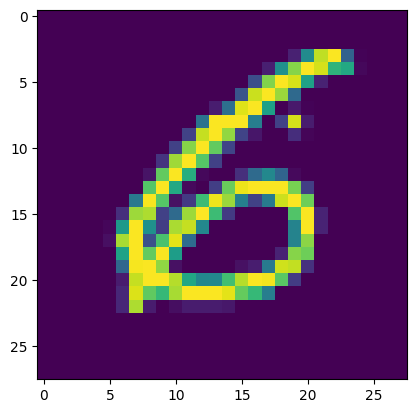

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

pixels = X_train.iloc[4,:].values
# print(type(pixels))
# print(pixels.shape)

image = pixels.reshape(28,28)

plt.imshow(image)


In [120]:
X_train.shape

(8000, 784)

# **Creat ANN Network**

In [121]:
# Model Creation
model = Sequential([
    Dense(64, activation='relu', input_shape = (X_train.shape[-1],) ), # Input Layer
    Dropout(0.1),
    Dense(32, activation='relu'), # HiddenLayer
    Dense(10, activation='softmax') # Output layer
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
# compile the model
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [123]:
# Model summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

Implement Early stopping

In [124]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    verbose = 1,
    patience = 2
)

In [125]:
# Train a ANN Model

history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs = 25, callbacks = early_stopping)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4600 - loss: 6.7983 - val_accuracy: 0.5920 - val_loss: 1.3663
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6286 - loss: 1.2234 - val_accuracy: 0.7090 - val_loss: 0.9725
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7064 - loss: 0.9164 - val_accuracy: 0.7995 - val_loss: 0.7977
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7535 - loss: 0.7664 - val_accuracy: 0.8085 - val_loss: 0.7215
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7933 - loss: 0.6606 - val_accuracy: 0.8295 - val_loss: 0.7160
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8109 - loss: 0.6025 - val_accuracy: 0.8460 - val_loss: 0.6321
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8232 - loss: 0.5515 - val_accuracy: 0.8725 - val_loss: 0.6604
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8370 - loss: 0.5135 - val_accuracy: 0.

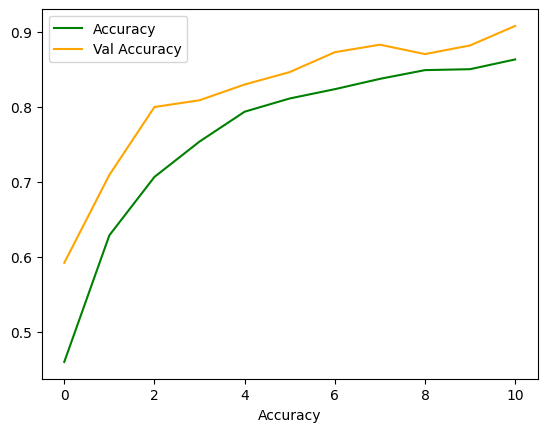

In [126]:
# Plot a Visuals of accuracy curve

plt.plot(history.history['accuracy'], color = 'green', label='Accuracy')
plt.plot(history.history['val_accuracy'], color = 'orange', label='Val Accuracy')
plt.xlabel('Accuracy')
plt.legend()
plt.show()



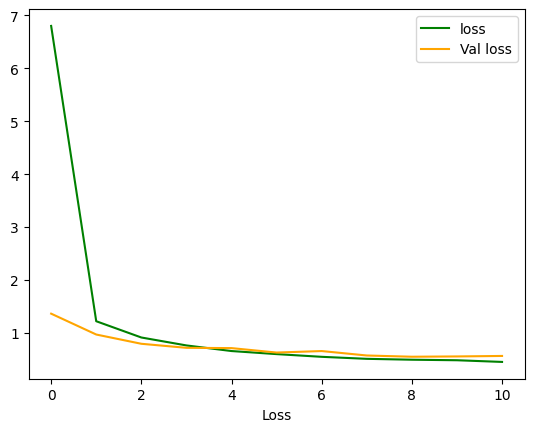

In [127]:
# Plot a Visuals of loss curve

plt.plot(history.history['loss'], color = 'green', label='loss')
plt.plot(history.history['val_loss'], color = 'orange', label='Val loss')
plt.xlabel('Loss')
plt.legend()
plt.show()

# *Trying hyperparameter Tuning*

In [128]:
import keras_tuner as kt
# Tune activation function, number of layers and number of neuron per layer
class Tuner(kt.HyperModel):
  def __init__(self, input_shape, num_classes):
    self.input_shape = input_shape  # Input Shape
    self.num_classes = num_classes  # Number of output classes

  def build(self, hp):


    chosen_layers = hp.Int('layers', min_value = 1, max_value = 4, step = 1)

    model = Sequential() # Empty layer
    model.add(Input(shape = self.input_shape)) # Input layer

    for i in range(chosen_layers):
      chosen_activation = hp.Choice('activation', ['relu', 'tanh', 'elu', 'gelu', 'selu'])
      chosen_units = hp.Int('neuron', min_value = 8, max_value=256, step = 8)

      # Add a hidden layers
      model.add(Dense(units = chosen_units, activation = chosen_activation))

    # Add a Output layers
    model.add(Dense(units = self.num_classes, activation = 'softmax' if num_classes > 1 else 'sigmoid'))

    # Compile the model
    model.compile(
        optimizer = 'adam',
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )

    return model



In [129]:
input_shape = (X_train.shape[-1],)
num_classes = len(Y_train.unique())

tuner = kt.RandomSearch(
    Tuner(input_shape, num_classes),
    objective='val_accuracy',
    max_trials = 10,
    directory = 'Sequential_tuning',
    project_name = 'Tuner'
)

Reloading Tuner from Sequential_tuning/Tuner/tuner0.json


In [130]:
tuner.search(X_train, Y_train, validation_data = (X_test, Y_test), epochs = 10)

In [131]:
tuner.get_best_hyperparameters()[0].values

{'layers': 1, 'activation': 'gelu', 'neuron': 224}

In [132]:
tuner.get_best_models()[0].summary()

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 224)            │       175,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,090 (695.66 KB)

 Trainable params: 178,090 (695.66 KB)

 Non-trainable params: 0 (0.00 B)

# Created a Best Neural Network using hyperparameter tuning

In [133]:

best_model = Sequential([
    Input(shape = input_shape),
    Dense(units = 224, activation='gelu'),
    Dense(units = 10, activation = 'softmax')
])

best_model.compile(
    optimizer= 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [134]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 224)            │       175,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,090 (695.66 KB)

 Trainable params: 178,090 (695.66 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
# Train the best Model

history = best_model.fit(X_train, Y_train, validation_data = (X_test, Y_test), epochs = 15, callbacks = early_stopping)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8298 - loss: 10.6768 - val_accuracy: 0.8700 - val_loss: 5.1487
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9319 - loss: 1.8523 - val_accuracy: 0.8935 - val_loss: 4.1609
Epoch 2: early stopping


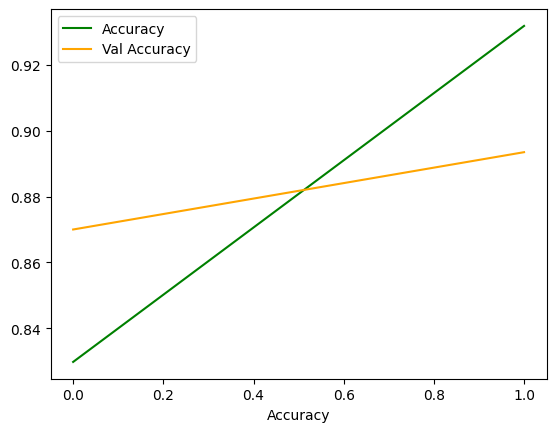

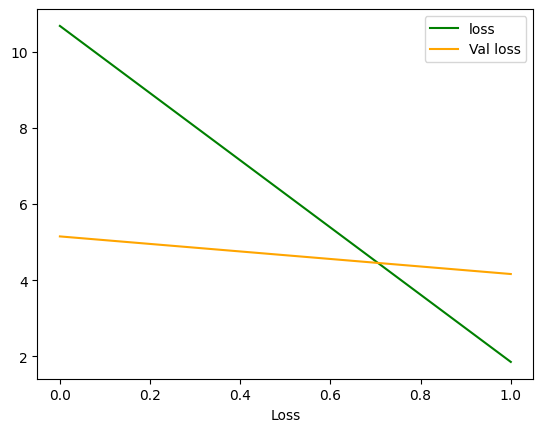

In [136]:
# Plot a Visuals of accuracy curve

plt.plot(history.history['accuracy'], color = 'green', label='Accuracy')
plt.plot(history.history['val_accuracy'], color = 'orange', label='Val Accuracy')
plt.xlabel('Accuracy')
plt.legend()
plt.show()


# Plot a Visuals of loss curve

plt.plot(history.history['loss'], color = 'green', label='loss')
plt.plot(history.history['val_loss'], color = 'orange', label='Val loss')
plt.xlabel('Loss')
plt.legend()
plt.show()
